# ASL Sign Language Interpreter
ResNet18-basierter Klassifikator für das American Sign Language Alphabet (29 Klassen).

In [1]:
import os
import ssl

import torch
import cv2
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# --- Konfiguration ---
DATA_DIR    = "/Users/fabianland/Documents/HS-Esslingen/6.Semester/machine_vision/lab/sign_language_interpreter/data/offline_composited"
MODEL_PATH  = "model_resnet18_asl_best.pth"
DEVICE      = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# --- Hyperparameter ---
NUM_CLASSES      = 29
IMG_SIZE         = 224
ROI_SIZE         = 600
BATCH_SIZE       = 64
NUM_WORKERS      = 4
TRAIN_VAL_SPLIT  = 0.8
NUM_EPOCHS       = 20
LR_HEAD          = 0.001
LR_FINETUNE      = 0.0001
UNFREEZE_EPOCH   = 5

print(f"PyTorch:  {torch.__version__}")
print(f"OpenCV:   {cv2.__version__}")
print(f"Device:   {DEVICE}")

PyTorch:  2.11.0
OpenCV:   4.13.0
Device:   mps


## 1. Daten-Exploration

Klassen (29): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']

  A: 6000 Bilder
  B: 6000 Bilder
  C: 6000 Bilder
  D: 6000 Bilder
  E: 6000 Bilder
  F: 6000 Bilder
  G: 6000 Bilder
  H: 6000 Bilder
  I: 6000 Bilder
  J: 6000 Bilder
  K: 6000 Bilder
  L: 6000 Bilder
  M: 6000 Bilder
  N: 6000 Bilder
  O: 6000 Bilder
  P: 6000 Bilder
  Q: 6000 Bilder
  R: 6000 Bilder
  S: 6000 Bilder
  T: 6000 Bilder
  U: 6000 Bilder
  V: 6000 Bilder
  W: 6000 Bilder
  X: 6000 Bilder
  Y: 6000 Bilder
  Z: 6000 Bilder
  del: 6000 Bilder
  nothing: 6000 Bilder
  space: 6000 Bilder

Bildgröße: (200, 200)


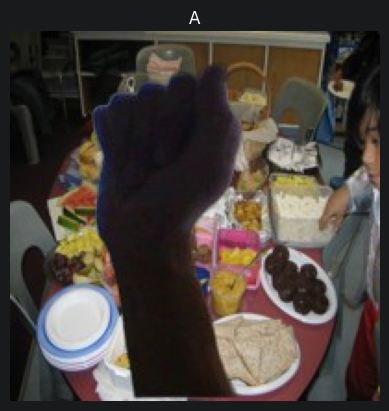

In [2]:
classes = sorted(os.listdir(DATA_DIR))
print(f"Klassen ({len(classes)}): {classes}\n")

for cls in classes:
    n = len(os.listdir(os.path.join(DATA_DIR, cls)))
    print(f"  {cls}: {n} Bilder")

# Beispielbild
sample_images = os.listdir(os.path.join(DATA_DIR, classes[0]))
img = Image.open(os.path.join(DATA_DIR, classes[0], sample_images[0]))
print(f"\nBildgröße: {img.size}")
plt.imshow(img)
plt.title(classes[0])
plt.axis("off")
plt.show()

## 2. Daten laden

In [3]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)
train_data, val_data = random_split(dataset, [TRAIN_VAL_SPLIT, 1 - TRAIN_VAL_SPLIT])

trainloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
valloader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Gesamtbilder:      {len(dataset)}")
print(f"Trainingsbilder:   {len(train_data)}")
print(f"Validationsbilder: {len(val_data)}")

Gesamtbilder:      174000
Trainingsbilder:   139201
Validationsbilder: 34799


## 3. Modell

In [4]:
ssl._create_default_https_context = ssl._create_unverified_context

model = models.resnet18(weights="DEFAULT")

# Friere alle Base-Gewichte ein
for param in model.parameters():
    param.requires_grad = False

# Neue letzte Schicht wird standardmäßig mit requires_grad=True erstellt
model.fc = nn.Linear(in_features=512, out_features=NUM_CLASSES)
model = model.to(DEVICE)

print(f"Letzte Schicht: {model.fc}")
print(f"Modell auf:     {DEVICE}")

Letzte Schicht: Linear(in_features=512, out_features=29, bias=True)
Modell auf:     mps


## 4. Training

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD)
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    if epoch == UNFREEZE_EPOCH:
        print("Entfriere alle Schichten für Fine-Tuning mit geringerer Lernrate...")
        for param in model.parameters():
            param.requires_grad = True
        optimizer = optim.Adam(model.parameters(), lr=LR_FINETUNE)

    model.train()
    running_loss = 0.0
    for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1:2d}/{NUM_EPOCHS} Training", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in tqdm(valloader, desc=f"Epoch {epoch+1:2d}/{NUM_EPOCHS} Validation", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            _, predicted = torch.max(model(images), 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | Loss: {running_loss/len(trainloader):.4f} | Val Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"           -> Gespeichert (beste Val Acc: {best_val_acc*100:.2f}%)")

print("Training abgeschlossen!")

Epoch  1/20 Training:   0%|          | 0/2176 [00:04<?, ?it/s]

Epoch  1/20 Validation:   0%|          | 0/544 [00:04<?, ?it/s]

Epoch  1/20 | Loss: 2.0029 | Val Acc: 51.15%
           -> Gespeichert (beste Val Acc: 51.15%)


Epoch  2/20 Training:   0%|          | 0/2176 [00:24<?, ?it/s]

Epoch  2/20 Validation:   0%|          | 0/544 [00:04<?, ?it/s]

...

Epoch  4/20 | Loss: 1.5810 | Val Acc: 54.65%


Epoch  5/20 Training:   0%|          | 0/2176 [00:04<?, ?it/s]

Epoch  5/20 Validation:   0%|          | 0/544 [00:05<?, ?it/s]

Epoch  5/20 | Loss: 1.5630 | Val Acc: 55.85%
           -> Gespeichert (beste Val Acc: 55.85%)
Entfriere alle Schichten für Fine-Tuning mit geringerer Lernrate...


Epoch  6/20 Training:   0%|          | 0/2176 [00:04<?, ?it/s]

## 5. Live-Inferenz

In [ ]:
model_live = models.resnet18(weights=None)
model_live.fc = nn.Linear(in_features=512, out_features=NUM_CLASSES)
model_live.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model_live = model_live.to(DEVICE)
model_live.eval()
print("Modell geladen!")

In [ ]:
transform_live = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class_names = dataset.classes
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h, w = frame.shape[:2]
    x = (w - ROI_SIZE) // 2
    y = (h - ROI_SIZE) // 2

    # ROI vom ungespiegelten Frame → Modell sieht dasselbe wie Trainingsdaten
    roi = frame[y:y + ROI_SIZE, x:x + ROI_SIZE]
    img_tensor = transform_live(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model_live(img_tensor), dim=1)
        confidence, predicted = torch.max(probs, 1)

    # Erst nach Inferenz spiegeln – nur für die Anzeige
    display = cv2.flip(frame, 1)
    label = f"{class_names[predicted.item()]}  {confidence.item()*100:.1f}%"
    cv2.rectangle(display, (x, y), (x + ROI_SIZE, y + ROI_SIZE), (0, 0, 255), 2)
    cv2.putText(display, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2)
    cv2.imshow("ASL Interpreter", display)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()